# Square Multiply
This Notebook demonstrates the correctness of the `square_multiply` reversing. 
We collected the 1000 instruction traces and instructed `spysgx` to reverse the instruction traces 
given the input file. The secrets were choosen randombly between 1 and $2^{30}$


In the end `spysgx` was able to correctly reverse the secret from 1000/1000 (100%) of the traces.

In [ ]:
%matplotlib inline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines


In [ ]:
import pathlib
import pandas as pd
import numpy as np

FOLDER_PATH = pathlib.Path("..") / "traces" / "square_multiply"
OUTPUT_PATH = pathlib.Path(".") / "square_multiply.csv"
RESULTS_PATH = pathlib.Path("..") / "traces" / "square_multiply"/ "results.csv"
# Get all trace files in FOLEDER_PATH
trace_files = list(FOLDER_PATH.glob("*.txt"))

# Create a dataframe with the trace files

# Create a list of lists
# Each list is a row in the dataframe
# The first column is the secret value (analysed from the filename)
# The rest of the colums are the instruction addresse

try: 
    # Try to load the CSV File
    df_final = pd.read_csv(OUTPUT_PATH)
except FileNotFoundError:
    data = []
    max_len = 0
    for trace_file in trace_files:
        # Get the secret value from the filename

        secret = int(trace_file.stem.split("_")[1])
        # Read the trace file
        with open(trace_file, "r") as f:
            trace = [int(x, 16) for x in f.read().splitlines()]
        # Add the secret value and the trace to the list of lists
        max_len = max(max_len, len(trace))
        data.append([trace_file.name, secret] + trace)

    # Create the dataframe
    df = pd.DataFrame(data, columns=["trace_file", "secret"] + [f"inst_{i}" for i in range(max_len)])
    # Join ith with results.csv
    # Contains the results from the reversing

    df_results = pd.read_csv(RESULTS_PATH, header = None)
    df_results.columns = ["trace_file", "reversed_secret"]
    df_results.head()
    
    # Join results and the secret together
    df_final = df.set_index("trace_file").join(df_results.set_index("trace_file"))
    # Move the reversed_secret to the front
    cols = df_final.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    df_final = df_final[cols]
    df_final.to_csv(OUTPUT_PATH, index = None)

In [ ]:
hex(4214784)

'0x405000'

In [ ]:
df_final.head()

,reversed_secret,secret,inst_0,inst_1,inst_2,inst_3,inst_4,inst_5,inst_6,inst_7,...,inst_1217,inst_1218,inst_1219,inst_1220,inst_1221,inst_1222,inst_1223,inst_1224,inst_1225,inst_1226
0,1000281936,1000281936,4214784,4214788,4214789,4214792,4214796,4214800,4214803,4214807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100052744,100052744,4214784,4214788,4214789,4214792,4214796,4214800,4214803,4214807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1004603981,1004603981,4214784,4214788,4214789,4214792,4214796,4214800,4214803,4214807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1006476588,1006476588,4214784,4214788,4214789,4214792,4214796,4214800,4214803,4214807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1007276375,1007276375,4214784,4214788,4214789,4214792,4214796,4214800,4214803,4214807,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualization
1 bits are in the middle while "0" bits go to the bottom

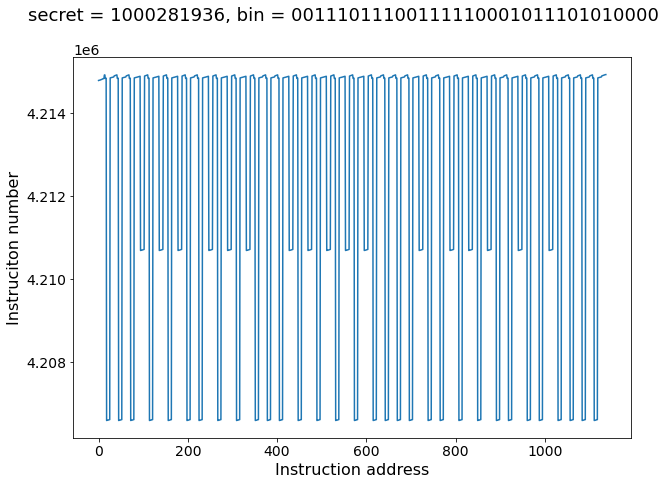

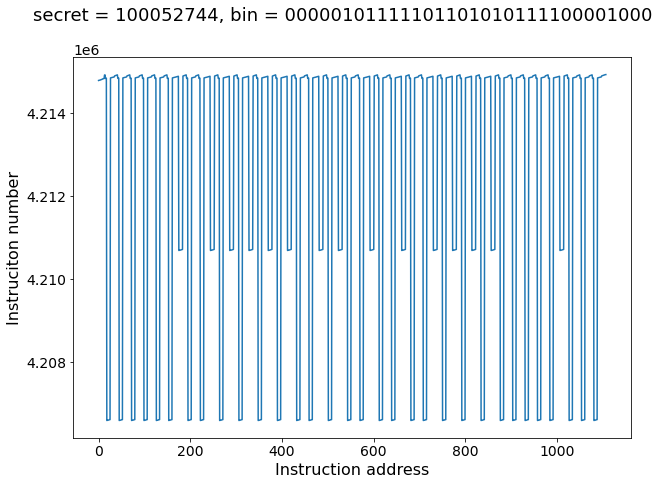

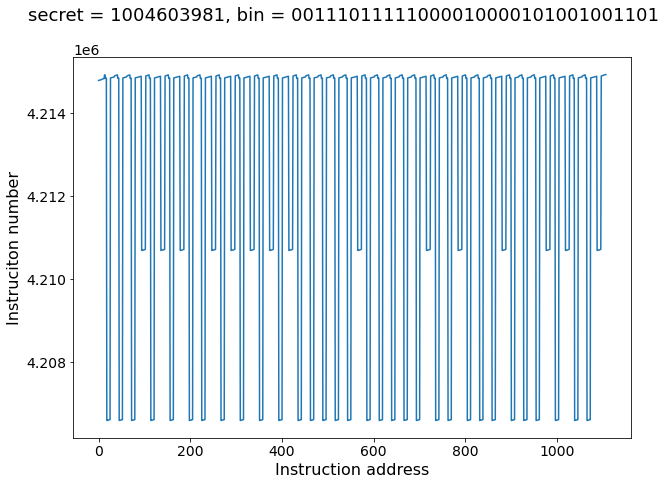

In [ ]:
# Show example traces
with plt.style.context('./arend.mplstyle'):
    for i in range(3):
        _, secret, *traces = df_final.loc[i].to_list()[:-1]
        secret = int(secret)
        fig, ax = plt.subplots()
        ax.plot(traces)
        ax.set_xlabel("Instruction address")
        ax.set_ylabel("Instruciton number")
        fig.suptitle(f"secret = {secret}, bin = {secret:032b}", size = 18)

# Result
The reversing with symbolic execution worked for 100% of the time

In [ ]:
# Calculated 
correct = sum(df_final.secret == df_final.reversed_secret)/ len(df_final)
print(f"{correct * 100:.02f} Percent of the secrets were reversed correctly")

100.00 Percent of the secrets were reversed correctly


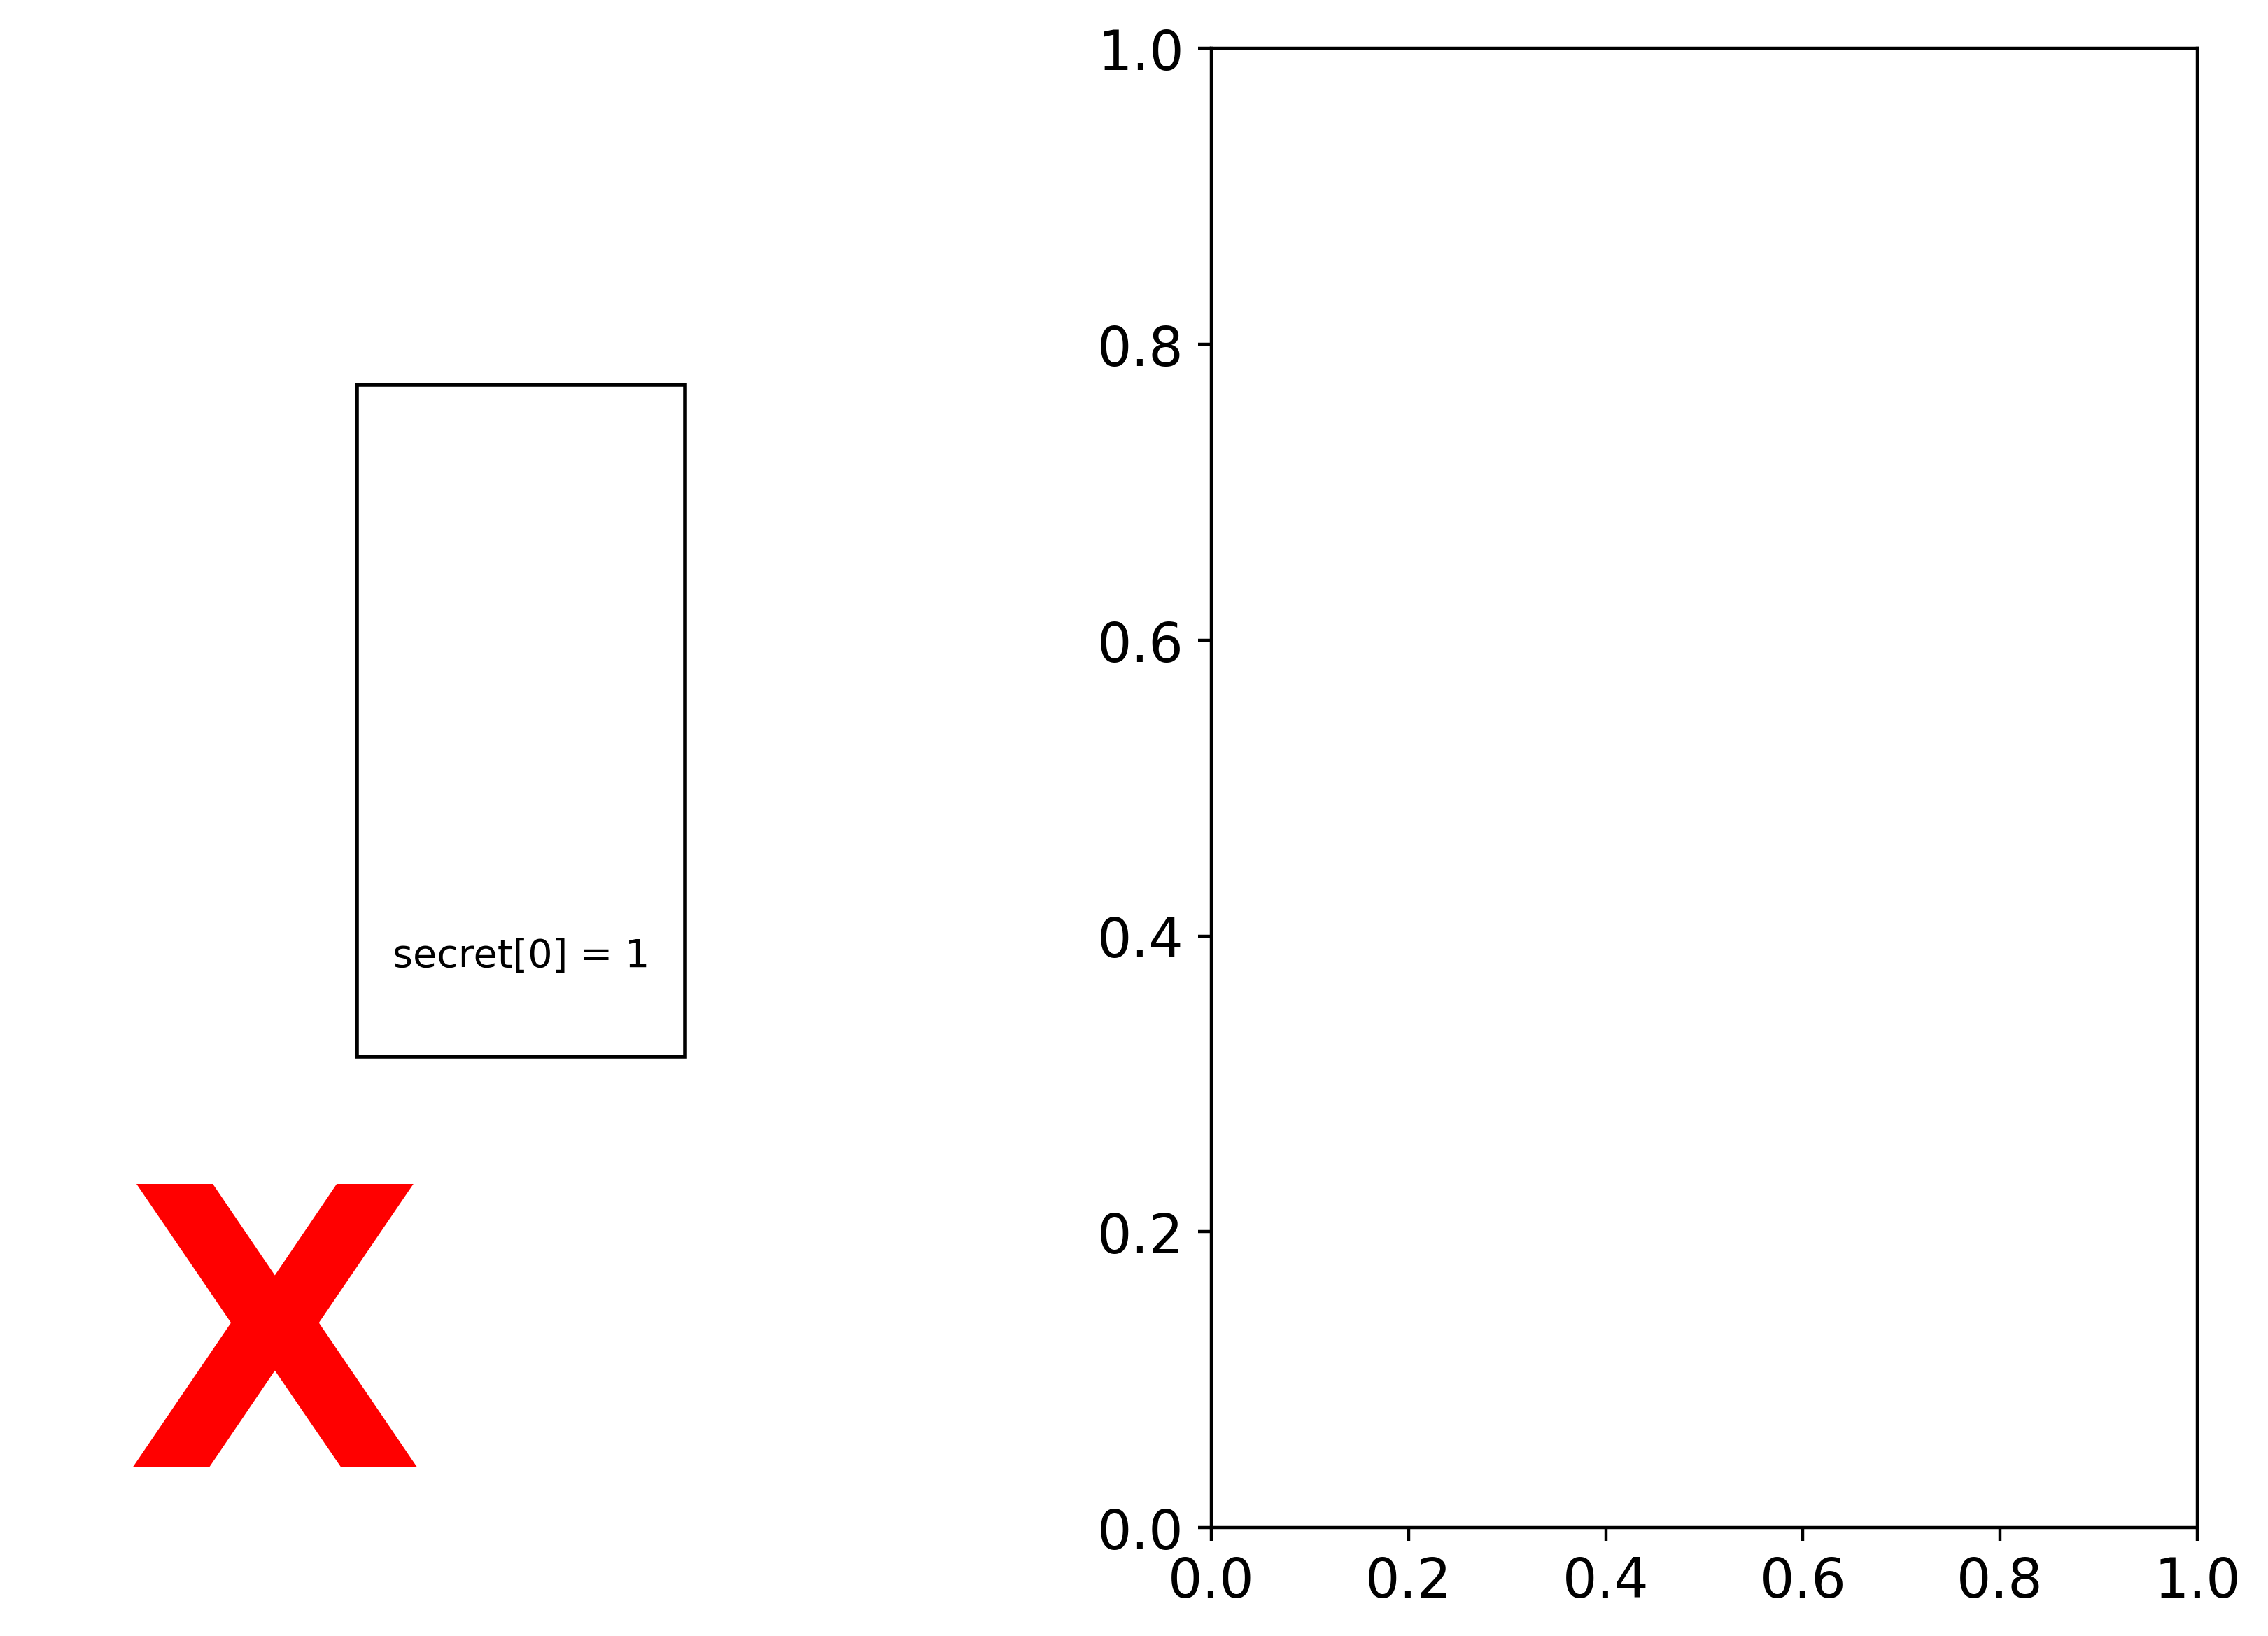

In [105]:
def draw_boxes(ax, cross_out = "none", box0_text = "", show12 = True):
    """Function to draw those boxes"""
    
    ax.cla() # Remove leftovers

    # Define the positions and sizes of the boxes
    box0_pos = [0.3, 0.6]
    box1_pos = [0, 0]
    box2_pos = [0.6, 0]
    box_width = 0.4
    box0_height = 1
    box_height = 0.3

    # Draw the boxes
    box0 = patches.Rectangle(box0_pos, box_width, box0_height, facecolor='none', edgecolor='black')
    box1 = patches.Rectangle(box1_pos, box_width, box_height, facecolor='none', edgecolor='green')
    box2 = patches.Rectangle(box2_pos, box_width, box_height, facecolor='none', edgecolor='red')

    # Add the boxes to the axes
    ax.add_patch(box0)
    if show12:
        ax.add_patch(box1)
        ax.add_patch(box2)

    # Add Text
    box0_name = box0_text
    box1_name = 'secret[i] == 1'
    box2_name = 'secret[i] == 0'
    box0_text_pos = [box0_pos[0] + box_width/2, box0_pos[1] + box_height/2]
    box1_text_pos = [box1_pos[0] + box_width/2, box1_pos[1] + box_height/2]
    box2_text_pos = [box2_pos[0] + box_width/2, box2_pos[1] + box_height/2]
    ax.text(*box0_text_pos, box0_name, ha='center', va='center')
    
    if show12:
        ax.text(*box1_text_pos, box1_name, ha='center', va='center')
        ax.text(*box2_text_pos, box2_name, ha='center', va='center')


    # Draw the arrows
    arrow_style = "Simple,tail_width=0.2,head_width=0.4,head_length=0.4"
    arrow_start = box0_pos
    arrow_start[0] = box0_pos[0] + 0.5 * box_width
    arrow0to1 = patches.FancyArrowPatch(arrow_start, [0.2, 0.3], color='black', arrowstyle=arrow_style)
    arrow0to2 = patches.FancyArrowPatch(arrow_start, [0.8, 0.3], color='black', arrowstyle=arrow_style)

    # Add the arrows to the axes
    if show12:
        ax.add_patch(arrow0to1)
        ax.add_patch(arrow0to2)

   

    # Add a big X on top of box 0
    x_pos = None
    if cross_out == "left":
        x_pos = box1_text_pos
    elif cross_out == "right":
        x_pos = box2_text_pos
    
        
    if x_pos:
        ax.text(*x_pos, 'X', fontsize=100, fontweight='bold', ha='center', va='center', color='red')

    # Set the limits of the axes
    ax.set_xlim(-.1, 1.1)
    ax.set_ylim(-.1, 2.1)
    ax.axis('off')

with plt.style.context(style):
    fig, ax = plt.subplots(1,2)    
    draw_boxes(ax[0], cross_out = "left", box0_text= "secret[0] = 1", show12=False)

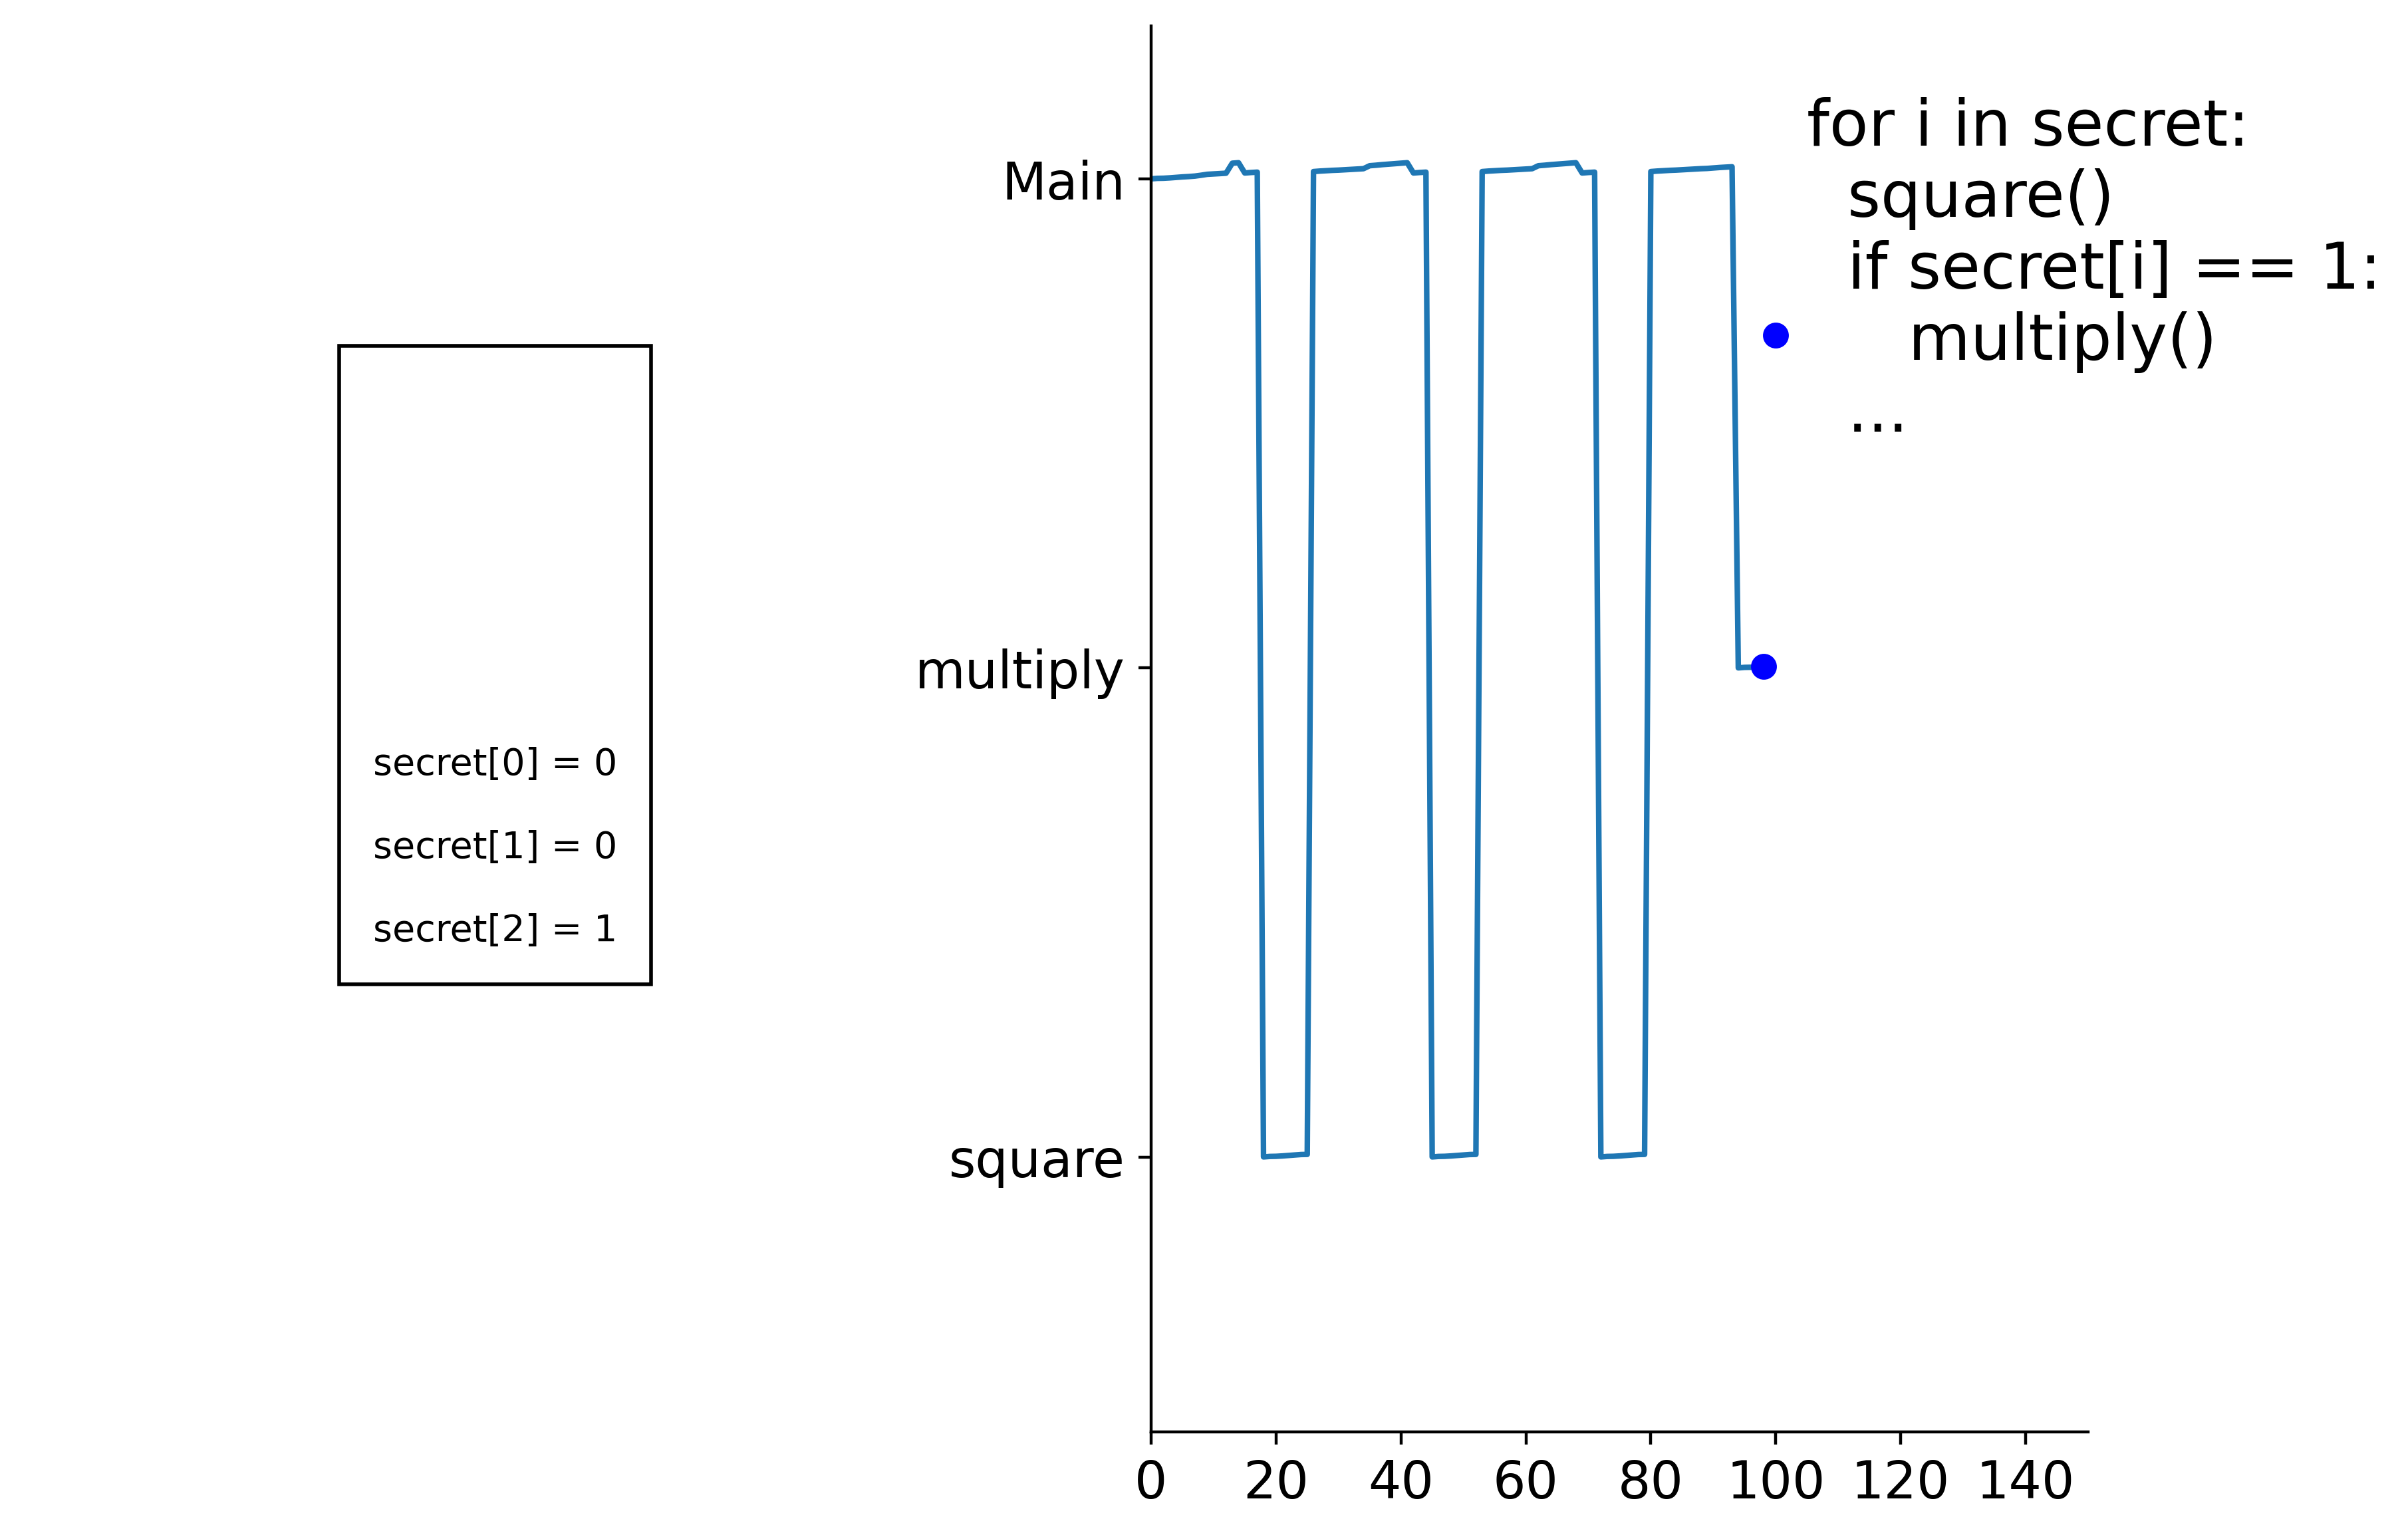

In [110]:
# Show example traces
PRODUCTION = False

style = "./animation.mplstyle" 
PAUSE_SIZE = 30
num_frames = 100 + 3 * PAUSE_SIZE

with plt.style.context(style):
    _, secret, *trace = df_final.loc[0].to_list()[:-1]
    secret = int(secret)
    fig, axes = plt.subplots(1,2)
    
    # Boxes
    box_ax = axes[0]
    draw_boxes
    
    # Trace
    ax = axes[1]
    ax.spines[['right', 'top']].set_visible(False)
        
    XRANGE = 100
    x = range(XRANGE)
    
    y = trace
    line, = ax.plot(x, y[:XRANGE])
    
    ax.set_xlim(0, XRANGE * 1.5)
    ax.set_ylim(0x402700, 0x405500)
    ax.set_yticks([0x405000, 0x404000, 0x403000])
    ax.set_yticklabels(["Main", "multiply", "square"])
    point, = ax.plot([], [], 'bo')
    text = ax.text(0.95, 0.05, '', transform=ax.transAxes,
                ha='right', va='bottom')
    
    code = ax.text(0.70, 0.95, '', transform=ax.transAxes,
            ha='left', va='top', size='xx-large')
    code.set_text("\n".join([
        "for i in secret:",
        "  square()",
        "  if secret[i] == 1:",
        "     multiply()",
        "  ...",
        
    ])
    
    )

    code_point, = ax.plot([], [], 'bo')
    found_bits = 0
    current_bit = 0

    true_point, = ax.plot([], [], 'go')
    false_point, = ax.plot([], [], 'ro')
    
    point_x_pos = 100
    addrs = {
        "start": 0x4051a0,
    }
    for i, name in enumerate(["square", "if", "multiply", "then"], 1):
        addrs[name] = addrs["start"] - 0x240 * i
        
    code_point.set_data(point_x_pos, addrs["start"])

    CNT_DRAW_SPLIT = 10
    # Split
    draw_split = 0
    box0_text = ""
    cross_out = "none"
    
    offset = 0
    pause = 0
    
    def animate(i):
        
        global found_bits
        global current_bit
        global draw_split
        global box0_text
        global cross_out
        global offset
        global pause
        global PAUSE_SIZE
        i -= offset
        
        if pause > 0:
            pause -= 1
            offset += 1
            return line,
        
        print(f"{i}, {current_bit=}", end = "\r")
        current_bit = None
        # Symbolic execution
        if y[i] == 0x405057:
            current_bit = 1
            cross_out = "right"
            draw_split = CNT_DRAW_SPLIT   
            
        if y[i] == 0x40506E and y[i-1] == 0x405055:
            current_bit = 0
            cross_out = "left"
            draw_split = CNT_DRAW_SPLIT   
        
        if (draw_split > 0):
            draw_split -= 1
            
        if (draw_split in range(1, 8)):
            true_point.set_data(x[i-1:i], 0x404000)
            false_point.set_data(x[i-1:i], 0x405000)
            point.set_data(-1000, y[i-1:i])    
            draw_boxes(box_ax, cross_out = cross_out, box0_text= box0_text)
            if draw_split == 7:
                pause = PAUSE_SIZE
            
        else:
            true_point.set_data(-1000, 0x404000)
            false_point.set_data(-1000, 0x405000)
            point.set_data(x[i-1:i], y[i-1:i])
            draw_boxes(box_ax, cross_out = "none", box0_text= box0_text, show12=False)

            
        
        # Comparison
        # if y[i] == 0x405055:
            
        # Points
        if y[i] == 0x40506E:
            code_point.set_data(point_x_pos, addrs["then"])
        
        elif y[i] in range(0x404000, 0x405000):
            if draw_split == 0:
                draw_split = CNT_DRAW_SPLIT
            code_point.set_data(point_x_pos, addrs["multiply"])
            
        elif y[i] in range(0x403000, 0x404000):
            code_point.set_data(point_x_pos, addrs["square"])
        
        # Overwrite for if:
        if y[i] in range(0x405052, 0x405056):
            code_point.set_data(point_x_pos, addrs["if"])
        

        
        if current_bit is not None:
            box0_text += f'secret[{found_bits}] = {current_bit}\n\n'
            found_bits += 1
    
        return line,
        
    ani = animation.FuncAnimation(
        fig, animate, interval=20, blit=True, save_count=num_frames)

    
    writer = animation.FFMpegWriter(
            fps=10, metadata=dict(artist='Youheng'), bitrate=-1)
    
    ani.save("symbolic_execution.mp4", writer=writer)
        # with plt.style.context('./arend.mplstyle'):

    #     _, secret, *traces = df_final.loc[i].to_list()[:-1]
    #     secret = int(secret)
    #     fig, ax = plt.subplots()
    #     ax.plot(traces)
    #     ax.set_xlabel("Instruction address")
    #     ax.set_ylabel("Instruciton number")
    #     fig.suptitle(f"secret = {secret}, bin = {secret:032b}", size = 18)